# SQL Chunk → LLM Extraction → Graph

Pipeline:
1. **Deterministic split** — decompose SQL into logical chunks (CTEs, UNION branches, main query, target).
2. **Per-chunk LLM extraction** — run `SQL2GraphPipeline` on each chunk's SQL.
3. **Combined graph** — merge chunk structure + per-chunk column lineage into one node-link graph.


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "Notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import os
import json
import importlib

from dotenv import load_dotenv

load_dotenv(ROOT / ".env")

import Classes.helper_classes as helper_classes
import Classes.sql_chunk_classes as sql_chunk_classes
import Classes.sql2graph_classes as sql2graph_classes

helper_classes = importlib.reload(helper_classes)
sql_chunk_classes = importlib.reload(sql_chunk_classes)
sql2graph_classes = importlib.reload(sql2graph_classes)

SQLLogicalChunkParser = sql_chunk_classes.SQLLogicalChunkParser
SQL2GraphParser = sql2graph_classes.SQL2GraphParser
SQL2GraphLLMExtractor = sql2graph_classes.SQL2GraphLLMExtractor
SQL2GraphPipeline = sql2graph_classes.SQL2GraphPipeline
SQL2GraphVisualizer = sql2graph_classes.SQL2GraphVisualizer

HF_TOKEN = os.environ.get("HF_TOKEN")
MODEL = os.environ.get("MODEL_NAME", "Qwen/Qwen3-Coder-30B-A3B-Instruct")
PROVIDER = os.environ.get("PROVIDER", "scaleway")

if not HF_TOKEN:
    raise RuntimeError("HF_TOKEN is required. Add it to .env and restart the kernel.")

print(f"HF_TOKEN loaded: ...{HF_TOKEN[-6:]}")
print(f"Model: {MODEL} ({PROVIDER})")


/Users/nikolajabramov/PycharmProjects/llm4lineage/.venv/lib/python3.14/site-packages/langchain_core/_api/deprecation.py:27: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


HF_TOKEN loaded: ...OrZWkc
Model: Qwen/Qwen3-Coder-Next (novita)


In [2]:
data_path = ROOT / "data" / "SQL.txt"
if not data_path.exists():
    raise FileNotFoundError(f"Could not find {data_path}")

raw_sql = data_path.read_text(encoding="utf-8")
statements = [s.strip() for s in raw_sql.split(";") if s.strip()]
sql_to_test = statements[0]

# Demo controls
MAX_CHUNKS_TO_EXTRACT = 1  # set to None to extract all query/cte chunks
SCHEMA = None
DIALECT = None

print(f"Loaded {len(raw_sql):,} characters from {data_path}")
print(f"Using statement 1 ({len(sql_to_test):,} chars)")
print(sql_to_test[:800], "\n...")


Loaded 17,834 characters from /Users/nikolajabramov/PycharmProjects/llm4lineage/data/SQL.txt
Using statement 1 (17,833 chars)
INSERT INTO s_grnplm_vd_t_bvd_db_dmslcl.d_agr_cred  SELECT agr.agr_cred_id,
    agr.prnt_agr_cred_id,
    agr.info_system_id,
    agr.agr_num,
    agr.grntee_agr_num,
    agr.signed_dt,
    agr.issue_crncy_id,
    agr.eks_overdraft_flag,
    agr.agr_regls_type_id,
        CASE
            WHEN (agr.eks_issue_dt IS NOT NULL) THEN agr.eks_issue_dt
            WHEN ((agr.agr_cred_type_cd = '1'::text) AND (agr.eks_transhes_issue_dt IS NOT NULL)) THEN agr.eks_transhes_issue_dt
            ELSE aco_fst_iss.optn_issue_dt
        END AS issue_dt,
    agr.close_dt,
    agr.expiration_dt,
    agr.host_agr_cred_id,
    agr.host_crm_id,
    agr.eks_agr_cred_type_id,
    agr.agr_frame_id,
    agr.eks_rvlng_flag,
    agr.issue_int_org_id,
    agr.multi_crncy_flag,
    agr.eks_old_restruct_cnt,
    agr.e 
...


In [3]:
chunk_parser = SQLLogicalChunkParser(
    model=MODEL,
    provider=PROVIDER,
    hf_token=HF_TOKEN,
    max_new_tokens=4096,
    temperature=0.0,
    max_retries=2,
)

graph_parser = SQL2GraphParser()
graph_extractor = SQL2GraphLLMExtractor(
    model=MODEL,
    provider=PROVIDER,
    hf_token=HF_TOKEN,
    max_new_tokens=4096,
    temperature=0.0,
    max_retries=2,
)
graph_pipeline = SQL2GraphPipeline(
    llm_extractor=graph_extractor,
    parser=graph_parser,
)

print("Parsers initialized")


Parsers initialized


## Step 1 — Deterministic chunk split


In [4]:
chunk_result = chunk_parser.preparse(sql=sql_to_test, dialect=DIALECT)

chunks = chunk_result.get("chunks", [])
chunk_links = chunk_result.get("links", [])

print("Chunks:", len(chunks))
print("Chunk links:", len(chunk_links))
print("Statement type:", chunk_result.get("statement_type"))
print("Target table:", chunk_result.get("target_table"))
if chunk_result.get("warnings"):
    print("Warnings:")
    for warning in chunk_result["warnings"]:
        print(" -", warning)


Chunks: 4
Chunk links: 5
Statement type: insert
Target table: d_agr_cred


In [5]:
for chunk in chunks:
    preview = (chunk.get("sql") or "")[:120].replace("\n", " ")
    print(f"- {chunk['id']} ({chunk['chunk_type']}): {preview}...")

print("\nLinks:")
print(json.dumps(chunk_links, indent=2))


- d_agr_cred (target): d_agr_cred...
- branch_0 (query): SELECT agr.agr_cred_id, agr.prnt_agr_cred_id, agr.info_system_id, agr.agr_num, agr.grntee_agr_num, agr.signed_dt, agr.is...
- branch_1 (query): SELECT agr_cred.agr_cred_id, CAST(NULL AS BIGINT) AS prnt_agr_cred_id, agr_cred.info_system_id, agr_cred.agr_num, CAST(N...
- branch_2 (query): SELECT core.agr_cred_id, CAST(NULL AS BIGINT) AS prnt_agr_cred_id, core.info_system_id, coa.coa_num AS agr_num, CAST(NUL...

Links:
[
  {
    "source": "branch_0",
    "target": "branch_1",
    "link_type": "UNION ALL",
    "condition": ""
  },
  {
    "source": "branch_1",
    "target": "branch_2",
    "link_type": "UNION ALL",
    "condition": ""
  },
  {
    "source": "branch_0",
    "target": "d_agr_cred",
    "link_type": "INSERT",
    "condition": ""
  },
  {
    "source": "branch_1",
    "target": "d_agr_cred",
    "link_type": "INSERT",
    "condition": ""
  },
  {
    "source": "branch_2",
    "target": "d_agr_cred",
    "link_type": "INS

## Step 2 — LLM extraction per chunk


In [6]:
def is_extractable_chunk(chunk: dict) -> bool:
    if chunk.get("chunk_type") not in {"cte", "query"}:
        return False
    sql = (chunk.get("sql") or "").strip()
    return len(sql) >= 40 and sql.upper().startswith(("SELECT", "WITH", "INSERT"))


extractable = [c for c in chunks if is_extractable_chunk(c)]
if MAX_CHUNKS_TO_EXTRACT is not None:
    extractable = extractable[:MAX_CHUNKS_TO_EXTRACT]

print(f"Extractable chunks: {len(extractable)}")
for chunk in extractable:
    print(f"  - {chunk['id']} ({len(chunk['sql']):,} chars)")


Extractable chunks: 1
  - branch_0 (7,578 chars)


In [7]:
per_chunk_results = []

for chunk in extractable:
    chunk_id = chunk["id"]
    chunk_sql = chunk["sql"]
    print(f"\nExtracting chunk: {chunk_id} ...")

    result = graph_pipeline.run(
        sql=chunk_sql,
        schema=SCHEMA,
        dialect=DIALECT,
        include_visualization=False,
    )

    if "error" in result:
        print("  ERROR:", result["error"])
        if result.get("details"):
            print("  ", result["details"][:300])
    else:
        node_count = len(result.get("graph", {}).get("nodes", []))
        edge_count = len(result.get("graph", {}).get("links", []))
        print(f"  OK: {node_count} nodes, {edge_count} links")

    per_chunk_results.append(
        {
            "chunk_id": chunk_id,
            "chunk_type": chunk["chunk_type"],
            "sql_chars": len(chunk_sql),
            "pipeline_result": result,
        }
    )



Extracting chunk: branch_0 ...
  OK: 154 nodes, 94 links


## Step 3 — Merge into combined graph


In [8]:
import hashlib


def prefixed_node_id(chunk_id: str, node_id: str) -> str:
    return f"{chunk_id}::{node_id}"


def build_combined_graph(chunks, chunk_links, per_chunk_results):
    """Chunk nodes + chunk links + prefixed per-chunk column lineage subgraphs."""
    combined_nodes = []
    combined_links = []

    chunk_ids = {chunk["id"] for chunk in chunks}
    for chunk in chunks:
        combined_nodes.append(
            {
                "id": chunk["id"],
                "label": chunk.get("name") or chunk["id"],
                "node_type": "chunk",
                "chunk_type": chunk.get("chunk_type", "query"),
            }
        )

    for link in chunk_links:
        if link.get("source") not in chunk_ids or link.get("target") not in chunk_ids:
            continue
        combined_links.append(
            {
                "source": link["source"],
                "target": link["target"],
                "link_type": link.get("link_type", "JOIN"),
                "edge_type": "CHUNK_LINK",
                "condition": link.get("condition", ""),
            }
        )

    for item in per_chunk_results:
        chunk_id = item["chunk_id"]
        pipeline_result = item.get("pipeline_result") or {}
        if "error" in pipeline_result:
            continue

        subgraph = pipeline_result.get("graph") or {}
        sub_nodes = subgraph.get("nodes") or []
        sub_links = subgraph.get("links") or subgraph.get("edges") or []

        id_map = {}
        for node in sub_nodes:
            old_id = node.get("id") or node.get("name")
            if not old_id:
                continue
            new_id = prefixed_node_id(chunk_id, old_id)
            id_map[old_id] = new_id
            combined_nodes.append(
                {
                    **node,
                    "id": new_id,
                    "parent_chunk": chunk_id,
                }
            )
            combined_links.append(
                {
                    "source": chunk_id,
                    "target": new_id,
                    "link_type": "CONTAINS",
                    "edge_type": "CONTAINS",
                    "condition": "",
                }
            )

        for link in sub_links:
            source = id_map.get(link.get("source"), link.get("source"))
            target = id_map.get(link.get("target"), link.get("target"))
            if not source or not target:
                continue
            combined_links.append(
                {
                    "source": source,
                    "target": target,
                    "link_type": link.get("link_type") or link.get("edge_type") or "DERIVED_FROM",
                    "edge_type": link.get("edge_type") or link.get("link_type") or "DERIVED_FROM",
                    "condition": link.get("condition", ""),
                    "parent_chunk": chunk_id,
                }
            )

    return {
        "nodes": combined_nodes,
        "links": combined_links,
        "metadata": {
            "source_sql_hash": hashlib.sha256(sql_to_test.encode("utf-8")).hexdigest(),
            "chunk_count": len(chunks),
            "extracted_chunk_count": len([x for x in per_chunk_results if "error" not in (x.get("pipeline_result") or {})]),
            "pipeline": ["deterministic_chunk_split", "per_chunk_sql2graph", "graph_merge"],
        },
    }


combined_graph = build_combined_graph(chunks, chunk_links, per_chunk_results)
print("Combined graph:")
print("  nodes:", len(combined_graph["nodes"]))
print("  links:", len(combined_graph["links"]))


Combined graph:
  nodes: 158
  links: 253


In [9]:
print("Sample combined nodes:")
print(json.dumps(combined_graph["nodes"][:6], indent=2))
print("\nSample combined links:")
print(json.dumps(combined_graph["links"][:8], indent=2))


Sample combined nodes:
[
  {
    "id": "d_agr_cred",
    "label": "d_agr_cred",
    "node_type": "chunk",
    "chunk_type": "target"
  },
  {
    "id": "branch_0",
    "label": "branch_0",
    "node_type": "chunk",
    "chunk_type": "query"
  },
  {
    "id": "branch_1",
    "label": "branch_1",
    "node_type": "chunk",
    "chunk_type": "query"
  },
  {
    "id": "branch_2",
    "label": "branch_2",
    "node_type": "chunk",
    "chunk_type": "query"
  },
  {
    "node_type": "output_column",
    "alias": "agr_cred_id",
    "expression": "agr.agr_cred_id",
    "aggregate": false,
    "window_function": false,
    "id": "branch_0::output.agr_cred_id",
    "parent_chunk": "branch_0"
  },
  {
    "node_type": "source_column",
    "table_alias": "agr",
    "column": "agr_cred_id",
    "id": "branch_0::agr.agr_cred_id",
    "parent_chunk": "branch_0"
  }
]

Sample combined links:
[
  {
    "source": "branch_0",
    "target": "branch_1",
    "link_type": "UNION ALL",
    "edge_type": "CHUN

Column lineage for chunk: branch_0


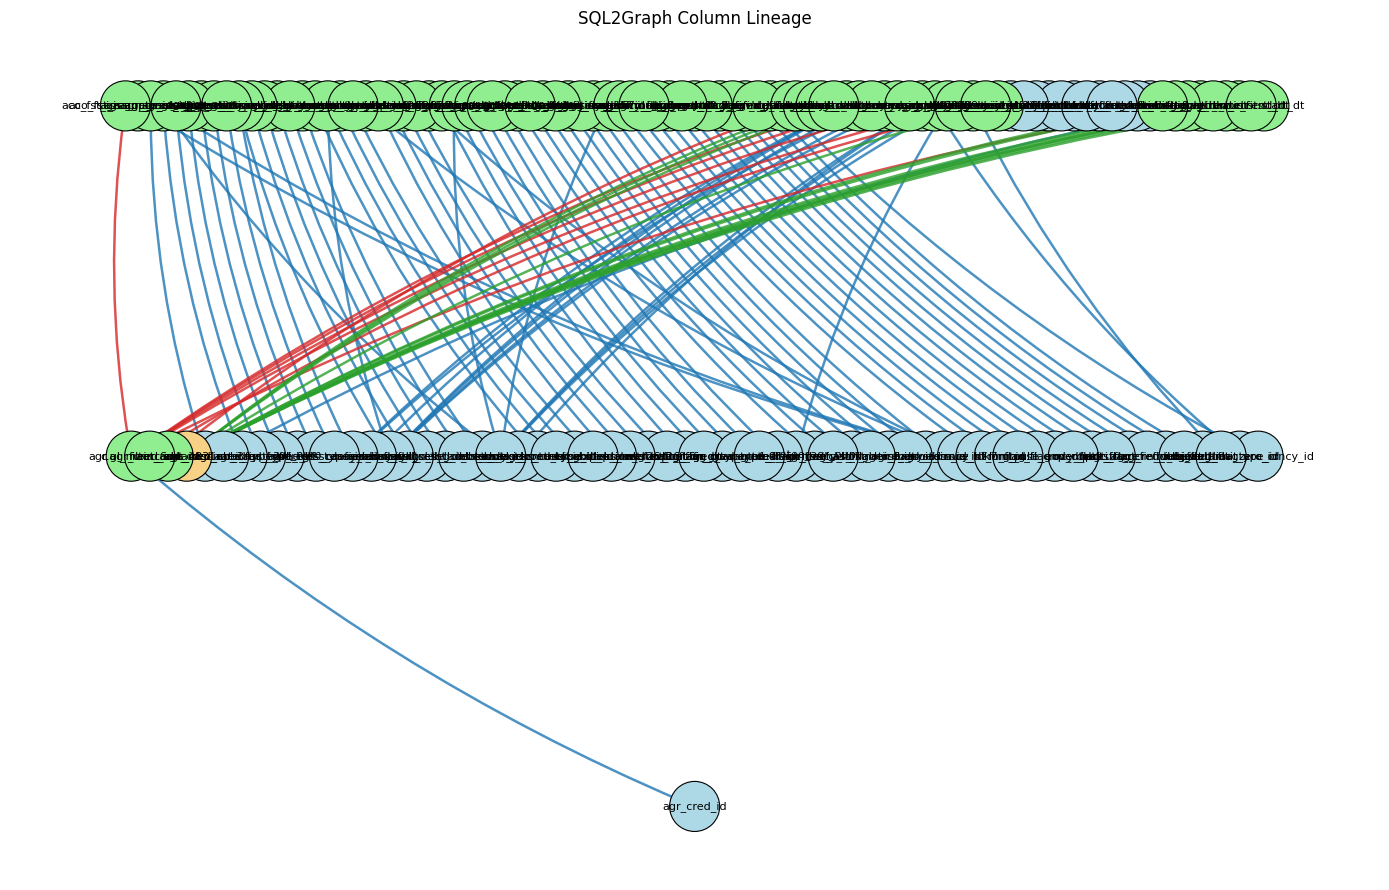

In [10]:
# Visualize one per-chunk column lineage subgraph (first successful extraction)
for item in per_chunk_results:
    result = item.get("pipeline_result") or {}
    if "error" in result:
        continue
    print(f"Column lineage for chunk: {item['chunk_id']}")
    SQL2GraphVisualizer.draw(result["graph"], figsize=(14, 9), layout="hierarchical")
    break


### Interactive chunk graph

Click a node to highlight its **full lineage**. Use **Clear selection** to reset.


In [11]:
chunk_node_link = chunk_parser.to_node_link(chunk_result)
SQL2GraphVisualizer.show_interactive(
    chunk_node_link,
    title="Step 1: Logical chunks (interactive)",
    height="640px",
)


    'data': [{'hoverinfo': 'skip',
              'legendgroup': 'edges',
       …

In [12]:
# Interactive per-chunk column lineage (first successful extraction)
for item in per_chunk_results:
    result = item.get("pipeline_result") or {}
    if "error" in result:
        continue
    print(f"Column lineage for chunk: {item['chunk_id']}")
    SQL2GraphVisualizer.show_interactive(
        result["graph"],
        title=f"Chunk {item['chunk_id']} column lineage",
        height="760px",
    )
    break
else:
    print("No successful per-chunk extraction yet. Run step 2 first or set MAX_CHUNKS_TO_EXTRACT.")


Column lineage for chunk: branch_0


    'data': [{'hoverinfo': 'skip',
              'legendgroup': 'edges',
       …

### Interactive combined graph

Chunks + per-chunk column nodes. Click any node for full lineage highlight.


In [13]:
SQL2GraphVisualizer.show_interactive(
    combined_graph,
    title="Step 3: Combined chunk + column lineage (interactive)",
    height="820px",
)


    'data': [{'hoverinfo': 'skip',
              'legendgroup': 'edges',
       …

In [14]:
output_path = ROOT / "data" / "sql_chunk_lineage_result.json"

payload = {
    "chunks": chunks,
    "chunk_links": chunk_links,
    "per_chunk": [
        {
            "chunk_id": item["chunk_id"],
            "chunk_type": item["chunk_type"],
            "error": item["pipeline_result"].get("error"),
            "graph": item["pipeline_result"].get("graph"),
            "warnings": item["pipeline_result"].get("warnings"),
        }
        for item in per_chunk_results
    ],
    "combined_graph": combined_graph,
}

output_path.write_text(json.dumps(payload, indent=2), encoding="utf-8")
print(f"Saved to {output_path}")


Saved to /Users/nikolajabramov/PycharmProjects/llm4lineage/data/sql_chunk_lineage_result.json
